In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

#rc('font',**{'family':'serif','serif':['Times New Roman']})
#rc('text', usetex=True)

In [47]:
""""
Omega = np.load('Omega_Ver.npy')
cantidad = np.sum((Omega != 0) & (Omega != 1))

#print("Cantidad de valores distintos de 0 y 1:", cantidad)
valores = Omega[(Omega != 0) & (Omega != 1)]

#print(valores)
filas, columnas = np.where((Omega != 0) & (Omega != 1))
#filas, columnas = np.where((Omega == 0))

for i, j in zip(filas, columnas):
    print(f"Omega[{i},{j}] = {Omega[i,j]}")
"""

'"\nOmega = np.load(\'Omega_Ver.npy\')\ncantidad = np.sum((Omega != 0) & (Omega != 1))\n\n#print("Cantidad de valores distintos de 0 y 1:", cantidad)\nvalores = Omega[(Omega != 0) & (Omega != 1)]\n\n#print(valores)\nfilas, columnas = np.where((Omega != 0) & (Omega != 1))\n#filas, columnas = np.where((Omega == 0))\n\nfor i, j in zip(filas, columnas):\n    print(f"Omega[{i},{j}] = {Omega[i,j]}")\n'

In [44]:
avg_repair_inter = np.load('F_inter_first.npy')
print(np.max(avg_repair_inter))

1.0562984019659731


## Dañados primero

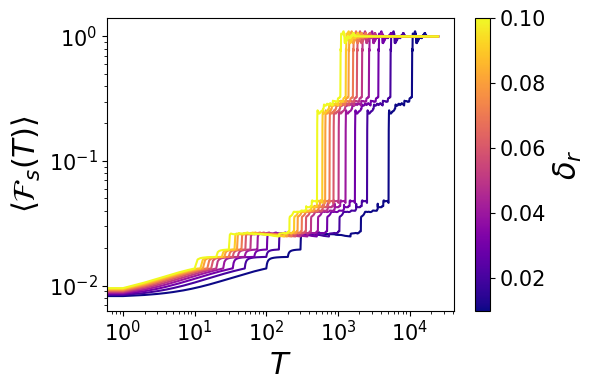

In [8]:
avg_repair = np.load('F_inter_first_worst_1.npy',
                     allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
deltas_r = np.linspace(0.01, 0.1, 10)

t_repair = np.arange(T_repair + 1)

# --- COLORMAP ---
colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

# --- FIGURA ---
plt.figure(figsize=(6, 4), facecolor="white")

# --- CURVAS ---
for d in deltas_r:
    color = colormap(norm(d))

    plt.loglog(
        t_repair,
        avg_repair[d],
        color=color,
        linewidth=1.5
    )

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())

cbar.set_label(r'$\delta_r$', fontsize=22)
cbar.ax.tick_params(labelsize=15)

# --- ETIQUETAS ---
plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)

# --- TICKS ---
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# --- AJUSTE FINAL ---
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_inter_worst_1.pdf',
            bbox_inches="tight")

plt.show()

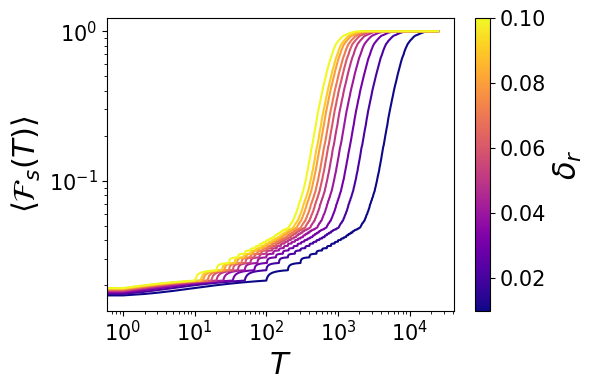

In [9]:
avg_repair = np.load('F_inter_first_worst.npy',
                     allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
deltas_r = np.linspace(0.01, 0.1, 10)

t_repair = np.arange(T_repair + 1)

# --- COLORMAP ---
colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

# --- FIGURA ---
plt.figure(figsize=(6, 4), facecolor="white")

# --- CURVAS ---
for d in deltas_r:
    color = colormap(norm(d))

    plt.loglog(
        t_repair,
        avg_repair[d],
        color=color,
        linewidth=1.5
    )

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())

cbar.set_label(r'$\delta_r$', fontsize=22)
cbar.ax.tick_params(labelsize=15)

# --- ETIQUETAS ---
plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)

# --- TICKS ---
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# --- AJUSTE FINAL ---
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_inter_worst.pdf',
            bbox_inches="tight")

plt.show()

## Mejores primero

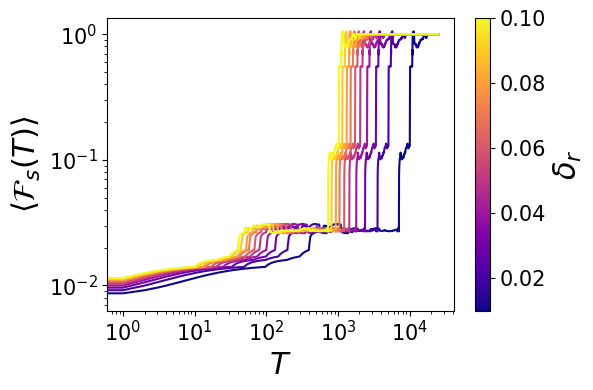

In [10]:
avg_repair = np.load('F_inter_first_best_1.npy',
                     allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
deltas_r = np.linspace(0.01, 0.1, 10)

t_repair = np.arange(T_repair + 1)

# --- COLORMAP ---
colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

# --- FIGURA ---
plt.figure(figsize=(6, 4), facecolor="white")

# --- CURVAS ---
for d in deltas_r:
    color = colormap(norm(d))

    plt.loglog(
        t_repair,
        avg_repair[d],
        color=color,
        linewidth=1.5
    )

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())

cbar.set_label(r'$\delta_r$', fontsize=22)
cbar.ax.tick_params(labelsize=15)

# --- ETIQUETAS ---
plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)

# --- TICKS ---
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# --- AJUSTE FINAL ---
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_inter_best_1.pdf',
            bbox_inches="tight")

plt.show()

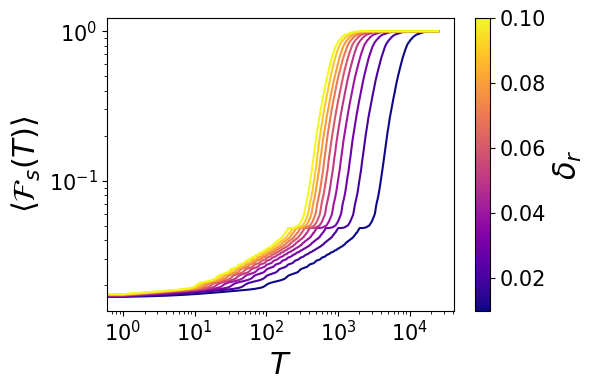

In [11]:
avg_repair = np.load('F_inter_first_best.npy',
                     allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
deltas_r = np.linspace(0.01, 0.1, 10)

t_repair = np.arange(T_repair + 1)

# --- COLORMAP ---
colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

# --- FIGURA ---
plt.figure(figsize=(6, 4), facecolor="white")

# --- CURVAS ---
for d in deltas_r:
    color = colormap(norm(d))

    plt.loglog(
        t_repair,
        avg_repair[d],
        color=color,
        linewidth=1.5
    )

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())

cbar.set_label(r'$\delta_r$', fontsize=22)
cbar.ax.tick_params(labelsize=15)

# --- ETIQUETAS ---
plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)

# --- TICKS ---
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# --- AJUSTE FINAL ---
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_inter_best.pdf',
            bbox_inches="tight")

plt.show()